In [1]:
import scanpy as sc
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
adata = sc.read_h5ad("/home/lixiangyu/zr/Annotate/ANNOTATE_new/9_annotate_level3/0521_no_Basophil/output_allhuman/scPoli_concat_level3_marker_all_metadata.h5ad")
adata_mouse = sc.read_h5ad("/home/lixiangyu/zr/Annotate/ANNOTATE_new/9_annotate_level3/0521_no_Basophil/output_mouse/scPoli_concat_level3_marker_allmouse.h5ad")

In [3]:
adata

AnnData object with n_obs × n_vars = 1004247 × 28868
    obs: 'sample', 'dataset', 'symptoms', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'cell_type_level1', 'scDblFinder.sample', 'gender', 'age', 'intervention', 'tissue', 'atlas_key', 'species', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'cell_type_level1_human', 'cell_type_level1_corrected', 'cell_type_level2', 'cell_type_level3', 'Plaque_type'
    var: 'original_gene_names', 'ensembl_id'
    uns: 'neighbors', 'umap'
    obsm: 'X_scPoli', 'X_umap'
    layers: 'counts', 'raw_decontXcounts', 'rounded_corrected_counts', 'uncorrected_counts'
    obsp: 'connectivities', 'distances'

In [4]:
adata_mouse

AnnData object with n_obs × n_vars = 564966 × 57692
    obs: 'dataset', 'sample', 'symptoms', 'gender', 'age', 'intervention', 'location', 'scDblFinder.sample', 'scDblFinder.class', 'scDblFinder.score', 'scDblFinder.weighted', 'scDblFinder.cxds_score', 'decontX_contamination', 'decontX_clusters', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'n_counts', 'tissue', 'cell_type_level1', 'barcode_for_match', 'match_id', 'leiden', 'cell_type_pred', 'cell_type_uncert', 'query', 'cell_type_pred_ref', 'atlas_key', 'cell_type_level1_corrected', 'cell_type_level2', 'cell_type_level3'
    var: 'original_gene_names'
    uns: 'cell_type_level1_corrected_colors', 'neighbors', 'umap'
    obsm: 'X_scPoli', 'X_umap', 'decontX_GSE131776_10_UMAP', 'decontX_GSE131776_11_UMAP', 'decontX_GSE131776_12_UMAP', 'decontX_GSE131776_13_UMAP', 'decontX_GSE131776_14_UMAP', 'decontX_GSE131776_15_UMAP', 'decontX_GSE131776_16_UMAP', 'decontX_GSE131776_17_UMAP', 'decontX_GSE131776_18

## Human

In [16]:
celltype_col = "cell_type_level1_corrected"
disease_col = "symptoms"
smc_name = "Smooth muscle cell"

obs = adata.obs.copy()
# 标记是否为 SMC
obs["is_smc"] = obs[celltype_col] == smc_name
# 计算每个疾病组中 SMC 的总体占比
disease_smc_prop = (
    obs
    .groupby(disease_col)
    .agg(
        total_cell_count=("is_smc", "size"),
        smc_cell_count=("is_smc", "sum")
    )
    .reset_index()
)

disease_smc_prop["smc_proportion"] = (
    disease_smc_prop["smc_cell_count"] / disease_smc_prop["total_cell_count"]
)
disease_smc_prop["smc_percentage"] = (
    disease_smc_prop["smc_proportion"] * 100
)

# 按 SMC 占比排序
disease_smc_prop = disease_smc_prop.sort_values(
    "smc_percentage",
    ascending=False
)

print(disease_smc_prop)

               symptoms  total_cell_count  smc_cell_count  smc_proportion  \
6               Healthy            103021           23175        0.224954   
1                    AD             32478            4660        0.143482   
5                   CBT              8266             893        0.108033   
2                  ATAA             38528            3677        0.095437   
10              Unknown             39638            3128        0.078914   
3       Atherosclerosis            428322           27901        0.065140   
4   Atherosclerosis,ISR             78175            3726        0.047662   
7                   IAA             22999             735        0.031958   
9                   TAA             83557            2228        0.026664   
0                   AAA            154435            1302        0.008431   
8                    MF             14828              42        0.002832   

    smc_percentage  
6        22.495414  
1        14.348174  
5        10.

/tmp/ipykernel_4146114/1993816351.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  obs


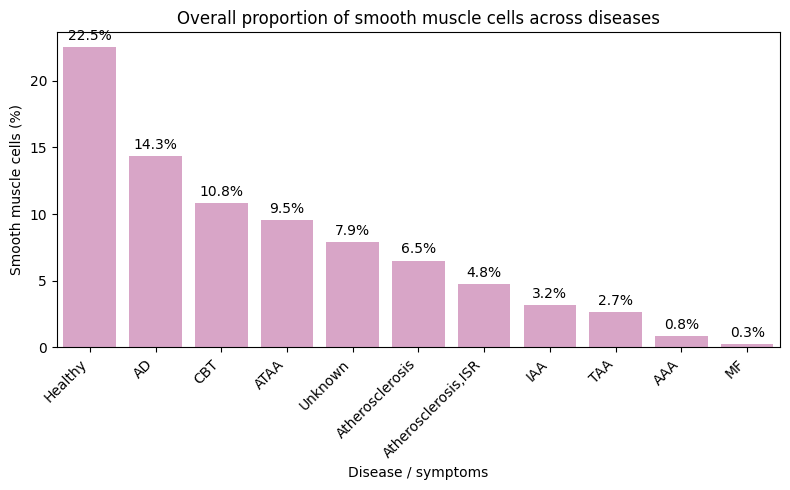

In [17]:
plt.figure(figsize=(8, 5))
# 明确指定 x 轴顺序
x_order = disease_smc_prop[disease_col].tolist()
ax = sns.barplot(
    data=disease_smc_prop,
    x=disease_col,
    y="smc_percentage",
    order=x_order,
    color="#E09CCA"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.xlabel("Disease / symptoms")
plt.ylabel("Smooth muscle cells (%)")
plt.title("Overall proportion of smooth muscle cells across diseases")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

   cell_type_level1_corrected  cell_count  percentage
0       Erythrocyte/Erythroid        3065    0.340092
1                   Mast cell        5983    0.663873
2                    Pericyte       14904    1.653747
3                    Monocyte       33360    3.701624
4              Dendritic cell       35108    3.895582
5         Natural killer cell       42910    4.761292
6          Smooth muscle cell       48292    5.358478
7                  Fibroblast       52723    5.850142
8            Endothelial cell       54095    6.002379
9                  Neutrophil       76106    8.444719
10                     B cell       85817    9.522251
11                 Macrophage       88896    9.863897
12                     T cell      359967   39.941924
除 Healthy 外，所有疾病中占比最高的细胞类型是：
cell_type_level1_corrected    Erythrocyte/Erythroid
cell_count                                     3065
percentage                                 0.340092
Name: 0, dtype: object


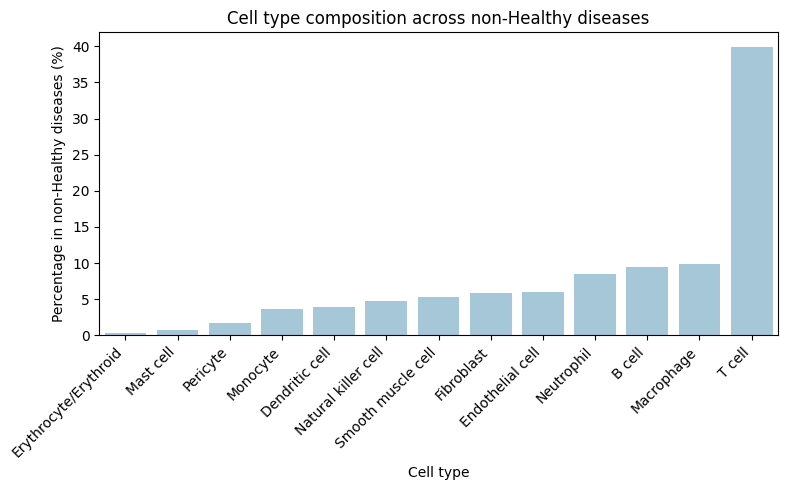

In [18]:
# =========================
# 看除 Healthy 外，所有疾病中的各细胞类型占比
# =========================

healthy_name = "Healthy"
# 筛选非 Healthy 细胞
obs_disease = obs[obs[disease_col] != healthy_name].copy()
# 统计非健康疾病中每个 cell type 的细胞数和比例
disease_celltype_prop = (
    obs_disease[celltype_col]
    .value_counts()
    .reset_index()
)
disease_celltype_prop.columns = [celltype_col, "cell_count"]

disease_celltype_prop["percentage"] = (
    disease_celltype_prop["cell_count"] /
    disease_celltype_prop["cell_count"].sum() * 100
)
disease_celltype_prop = disease_celltype_prop.sort_values(
    "percentage",
    ascending=True
).reset_index(drop=True)
print(disease_celltype_prop)

top_celltype = disease_celltype_prop.iloc[0]

x_order = disease_celltype_prop[celltype_col].tolist()


print("除 Healthy 外，所有疾病中占比最高的细胞类型是：")
print(top_celltype)
plt.figure(figsize=(8, 5))

sns.barplot(
    data=disease_celltype_prop,
    x=celltype_col,
    y="percentage",
    order=x_order,
    color="#9CCAE0"
)
plt.xlabel("Cell type")
plt.ylabel("Percentage in non-Healthy diseases (%)")
plt.title("Cell type composition across non-Healthy diseases")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

## Mouse

In [19]:
celltype_col = "cell_type_level1_corrected"
disease_col = "symptoms"
smc_name = "Smooth muscle cell"

obs = adata_mouse.obs.copy()

# 统一疾病名称
obs[disease_col] = obs[disease_col].astype(str).str.strip()
obs[disease_col] = obs[disease_col].replace({
    "Atherosclerosis+Diabetes": "Atherosclerosis",
    "atherosclerosis": "Atherosclerosis",
})
# 标记是否为 SMC
obs["is_smc"] = obs[celltype_col] == smc_name
# 计算每个疾病组中 SMC 的总体占比
disease_smc_prop = (
    obs
    .groupby(disease_col)
    .agg(
        total_cell_count=("is_smc", "size"),
        smc_cell_count=("is_smc", "sum")
    )
    .reset_index()
)
disease_smc_prop["smc_proportion"] = (
    disease_smc_prop["smc_cell_count"] / disease_smc_prop["total_cell_count"]
)

disease_smc_prop["smc_percentage"] = (
    disease_smc_prop["smc_proportion"] * 100
)
# 按 SMC 占比排序
disease_smc_prop = disease_smc_prop.sort_values(
    "smc_percentage",
    ascending=False
)
print(disease_smc_prop)

          symptoms  total_cell_count  smc_cell_count  smc_proportion  \
3          Healthy             65753           27163        0.413107   
2  Atherosclerosis            291919           72453        0.248196   
1              AAD             16872            4063        0.240813   
0              AAA            144049           23323        0.161910   
4              IMH             44717            2256        0.050451   
5               RA              1656               0        0.000000   

   smc_percentage  
3       41.310663  
2       24.819556  
1       24.081318  
0       16.191018  
4        5.045061  
5        0.000000  


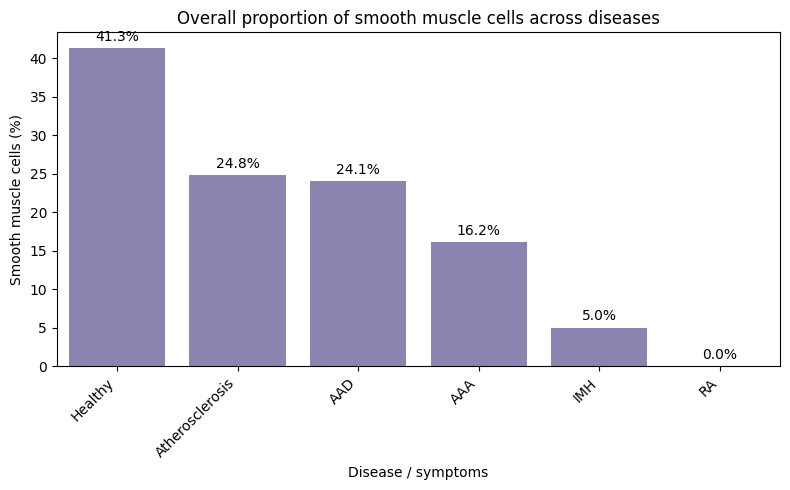

In [20]:
plt.figure(figsize=(8, 5))

ax = sns.barplot(
    data=disease_smc_prop,
    x=disease_col,
    y="smc_percentage",
    color="#867cb9"
)

for container in ax.containers:
    ax.bar_label(container, fmt="%.1f%%", padding=3)

plt.xlabel("Disease / symptoms")
plt.ylabel("Smooth muscle cells (%)")
plt.title("Overall proportion of smooth muscle cells across diseases")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

   cell_type_level1_corrected  cell_count  percentage
0                   Mast cell         163    0.032651
1                    Pericyte        1297    0.259809
2       Erythrocyte/Erythroid        1456    0.291659
3         Natural killer cell        3920    0.785236
4                    Monocyte       11964    2.396572
5                  Neutrophil       15082    3.021155
6            Endothelial cell       25188    5.045542
7              Dendritic cell       25346    5.077191
8                      B cell       25715    5.151108
9                      T cell       74305   14.884428
10         Smooth muscle cell      102095   20.451190
11                 Fibroblast      103302   20.692971
12                 Macrophage      109380   21.910487
除 Healthy 外，所有疾病中占比最高的细胞类型是：
cell_type_level1_corrected    Macrophage
cell_count                        109380
percentage                     21.910487
Name: 12, dtype: object


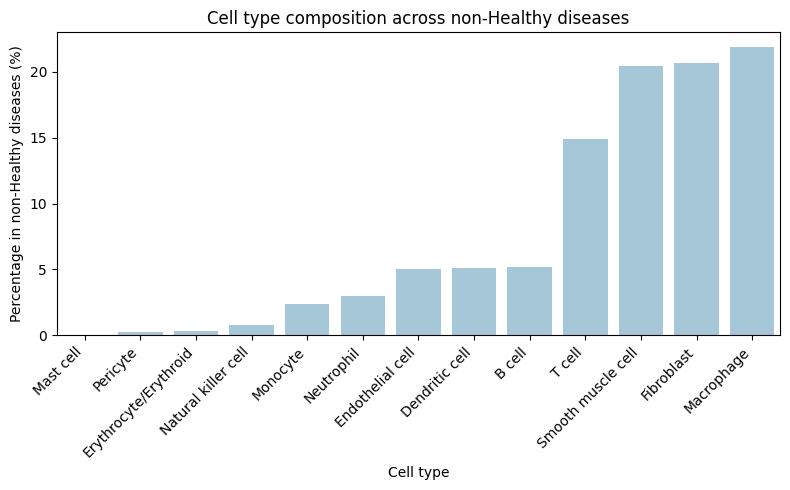

In [21]:
# =========================
# 看除 Healthy 外，所有疾病中的各细胞类型占比
# =========================

healthy_name = "Healthy"

# 筛选非 Healthy 细胞
obs_disease = obs[obs[disease_col] != healthy_name].copy()

# 统计非健康疾病中每个 cell type 的细胞数和比例
disease_celltype_prop = (
    obs_disease[celltype_col]
    .value_counts()
    .reset_index()
)

disease_celltype_prop.columns = [celltype_col, "cell_count"]

disease_celltype_prop["percentage"] = (
    disease_celltype_prop["cell_count"] /
    disease_celltype_prop["cell_count"].sum() * 100
)

# 按 percentage 从低到高排序
disease_celltype_prop = disease_celltype_prop.sort_values(
    "percentage",
    ascending=True
).reset_index(drop=True)

print(disease_celltype_prop)

top_celltype = disease_celltype_prop.iloc[-1]

print("除 Healthy 外，所有疾病中占比最高的细胞类型是：")
print(top_celltype)

plt.figure(figsize=(8, 5))

sns.barplot(
    data=disease_celltype_prop,
    x=celltype_col,
    y="percentage",
    order=disease_celltype_prop[celltype_col],
    color="#9CCAE0"
)

plt.xlabel("Cell type")
plt.ylabel("Percentage in non-Healthy diseases (%)")
plt.title("Cell type composition across non-Healthy diseases")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()